# MR4010 Navegación Autónoma

## Perceptron simple para Logsitics Regression

Se creará una neurona simple con dos pesos, un bias y la función sigmoide como función de activación.

Se explicará Cross Entropy como la Loss Function.

Se explicará Gradient Descent para reducir el error.

Lee el capítulo 4 del libro de texto:

Venturi, L. y Korda, K. (2020). Hands-On Vision and Behavior For Self-Driving Cars. Packt Publishing. Disponible en: https://learning.oreilly.com/library/view/hands-on-vision-and/9781800203587/B16322_FM_Final_NM_ePUB.xhtmlLinks to an external site.
Licencia: Copyright © 2020 Packt Publishing.

 

Lee el capítulo 2 del libro de texto:

Ranjan, S. y Senthamilarasu S.(2020). Applied Deep Learning and Computer Vision
for Self-Driving Cars. Packt Publishing Ltd. https://learning.oreilly.com/library/view/applied-deep-learning/9781838646301/?sso_link=yes&sso_link_from=ITESMLinks to an external site. 
Licencia: Copyright © 2020 Packt Publishing.


## Paso 1 - Instalacion de pytorch paar correr en GPU, para esto correr en terminal
Paso a paso

python -m pip install --upgrade pip setuptools wheel

python -m pip install --force-reinstall --no-cache-dir typing-extensions==4.12.2

python -m pip install --no-cache-dir `
  torch==2.7.1+cu128 `
  torchvision==0.22.1+cu128 `
  torchaudio==2.7.1+cu128 `
  --index-url https://download.pytorch.org/whl/cu128

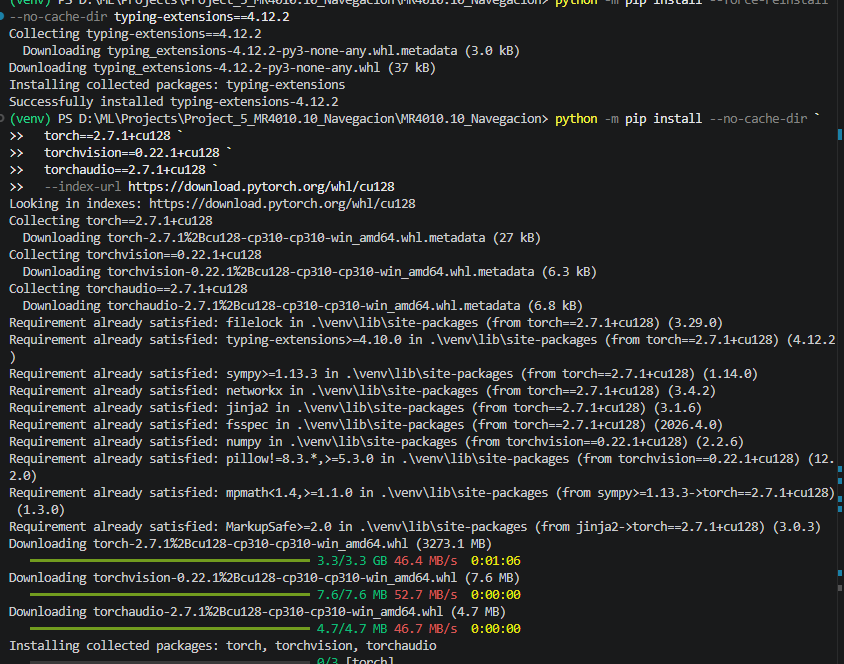

In [1]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Capability: (12, 0)


# Paso 2 — Cargar bibliotecas

Explicación rápida:

numpy: nos ayuda con matrices, vectores y operaciones matemáticas.

matplotlib: nos ayuda a graficar los datos y la frontera de decisión.

%matplotlib inline: permite que las gráficas aparezcan dentro del notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Paso 3 - Modelo de una neurona

Una neurona simple recibe entradas, las multiplica por pesos, suma un bias y pasa el resultado por una función de activación.

Para dos entradas:

$
z = x_1w_1 + x_2w_2 + b
$

En regresión logística, el resultado se transforma en probabilidad usando la función sigmoide:

$
p = \sigma(z) = \frac{1}{1 + e^{-z}}
$

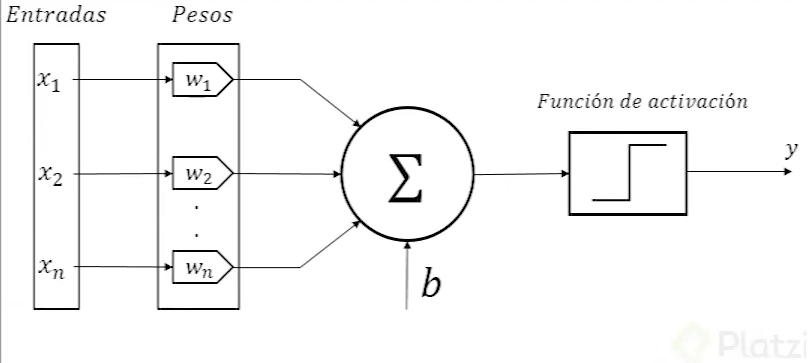

# Definición de la función de activación

La función sigmoide convierte cualquier valor real en un valor entre 0 y 1.

- Si el resultado está cerca de 0, el modelo predice clase 0.
- Si el resultado está cerca de 1, el modelo predice clase 1.
- Si el resultado es mayor o igual a 0.5, clasificamos como 1.

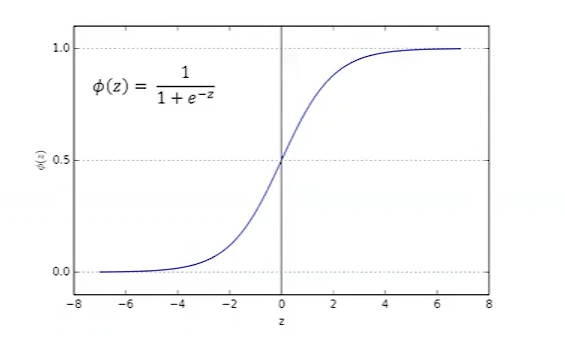

In [3]:
def sigmoid(score):
    return 1 / (1 + np.exp(-score))

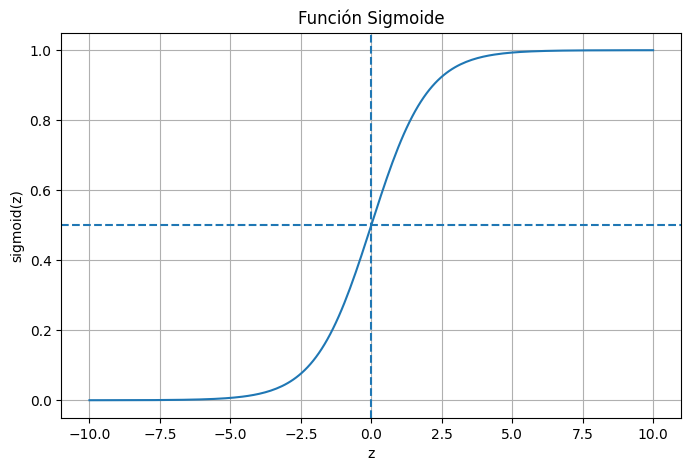

In [4]:
# Visualización de la función sigmoide

z = np.linspace(-10, 10, 200)

p = sigmoid(z)

plt.figure(figsize=(8,5))

plt.plot(z, p)

plt.axhline(0.5, linestyle='--')

plt.axvline(0, linestyle='--')

plt.xlabel('z')

plt.ylabel('sigmoid(z)')

plt.title('Función Sigmoide')

plt.grid(True)

plt.show()

# Cross Entropy para calcular el error

La función de activación regresa valores entre 0 y 1 y representa la probabilidad de clasificación del dato proporcionado.

Como el vector y es binario, el error se calcula usando Binary Cross Entropy:

$
J(w,b) = -\frac{1}{n}\sum \left[y\log(p) + (1-y)\log(1-p)\right]
$

Donde:

- y es la etiqueta real.
- p es la probabilidad calculada por la neurona.
- n es el número de puntos.

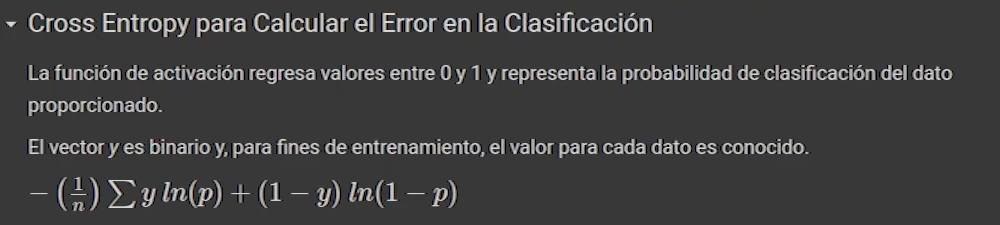

In [5]:
def calculate_error(line_parameters, points, y):

    n = points.shape[0]

    p = sigmoid(points @ line_parameters)

    epsilon = 1e-15

    p = np.clip(p, epsilon, 1 - epsilon)

    cross_entropy = -(1/n) * (
        np.log(p).T @ y +
        np.log(1-p).T @ (1-y)
    )

    return cross_entropy.item()

# Backpropagation y Gradient Descent

Gradient Descent ajusta los pesos en cada iteración para reducir la función de pérdida.

El gradiente para regresión logística se calcula como:

$
\nabla J = \frac{X^T(p-y)}{n}
$

Y los parámetros se actualizan así:

$
\theta = \theta - \alpha \nabla J
$

Donde:

- theta contiene w1, w2 y b.
- alpha es el learning rate.
- p-y es el error entre predicción y valor real.

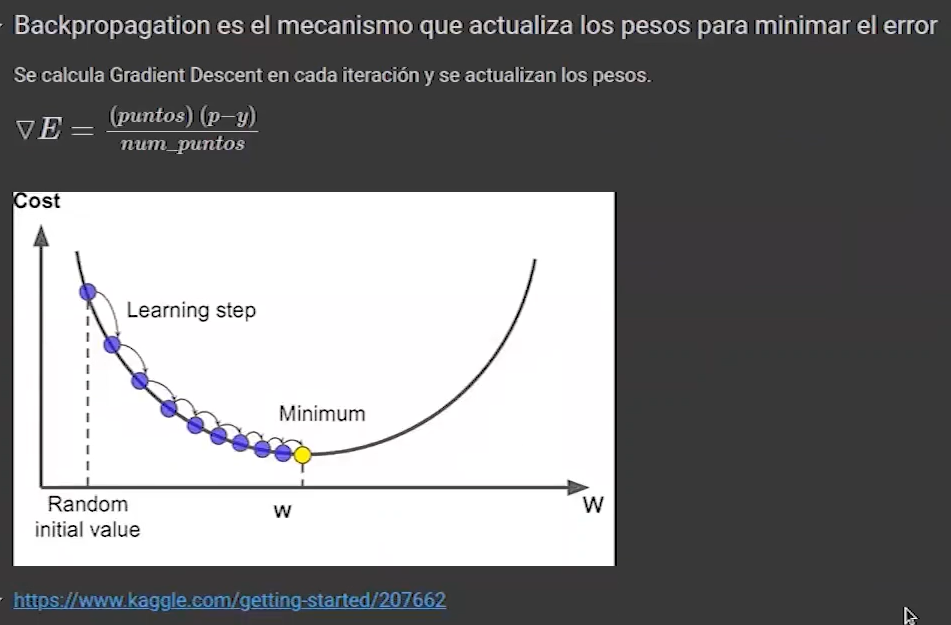

In [ ]:
def gradient_descent(
    line_parameters,
    points,
    y,
    lrate=0.06, ##- - - - - alpha
    epochs=2000,
    print_every=200
):

    n = points.shape[0]

    errors = []

    for i in range(epochs):

        p = sigmoid(points @ line_parameters)

        gradient = (points.T @ (p - y)) * (lrate / n)

        line_parameters = line_parameters - gradient

        error = calculate_error(
            line_parameters,
            points,
            y
        )

        errors.append(error)

        if i % print_every == 0:
            print(
                f'Epoch {i} | Error: {error:.5f}'
            )

    return line_parameters, errors

# Paso 4 - Crear dos grupos de datos aleatorios

Se crearán:

- 100 puntos en la parte superior.
- 100 puntos en la parte inferior.

La tercera columna será el bias.

In [ ]:
# Número de puntos - 200 datos a clasificar 100 superior y 100 inferior

n_pts = 100

# Semilla aleatoria para genenador

np.random.seed(0)

# Bias

bias = np.ones(n_pts)

# Región superior

top_region = np.array([

    np.random.normal(10, 2, n_pts),

    np.random.normal(12, 2, n_pts),

    bias

]).T

# Región inferior

bottom_region = np.array([

    np.random.normal(5, 2, n_pts),

    np.random.normal(6, 2, n_pts),

    bias

]).T

# Unión de regiones

all_points = np.vstack((

    top_region,
    bottom_region

))

print(all_points.shape)

(200, 3)


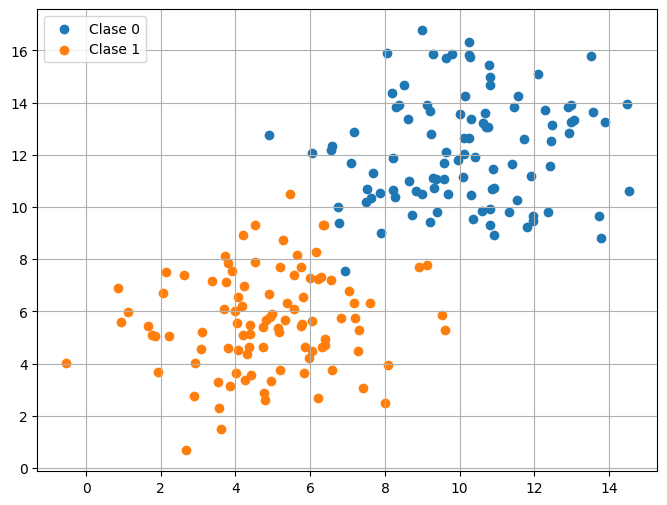

In [8]:
# Graficar datos

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    top_region[:,0],
    top_region[:,1],
    label='Clase 0'
)

ax.scatter(
    bottom_region[:,0],
    bottom_region[:,1],
    label='Clase 1'
)

ax.legend()

ax.grid(True)

plt.show()

# Paso 5 - Crear etiquetas del dataset

- La región superior será clase 0.
- La región inferior será clase 1.

In [9]:
y = np.array([

    np.zeros(n_pts),

    np.ones(n_pts)

]).reshape(n_pts * 2, 1)

print(y.shape)

(200, 1)


# Paso 6 - Inicializar parámetros de la neurona

Inicialmente:

- w1 = 0
- w2 = 0
- b = 0

In [10]:
w1 = 0
w2 = 0
b = 0

line_parameters = np.array([

    [w1],
    [w2],
    [b]

], dtype=float)

print(line_parameters)

print(line_parameters.shape)

[[0.]
 [0.]
 [0.]]
(3, 1)


# Paso 7 - Entrenamiento de la neurona

Usaremos:

- learning rate = 0.06
- 2000 épocas

In [11]:
line_parameters, errors = gradient_descent(

    line_parameters,

    all_points,

    y,

    lrate=0.06,

    epochs=2000

)

print(line_parameters)

Epoch 0 | Error: 0.70218
Epoch 200 | Error: 0.42919
Epoch 400 | Error: 0.32744
Epoch 600 | Error: 0.26914
Epoch 800 | Error: 0.23173
Epoch 1000 | Error: 0.20571
Epoch 1200 | Error: 0.18652
Epoch 1400 | Error: 0.17174
Epoch 1600 | Error: 0.15997
Epoch 1800 | Error: 0.15036
[[-0.32571582]
 [-0.50533931]
 [ 6.62630591]]


# Paso 8 -Graficar pérdida durante entrenamiento

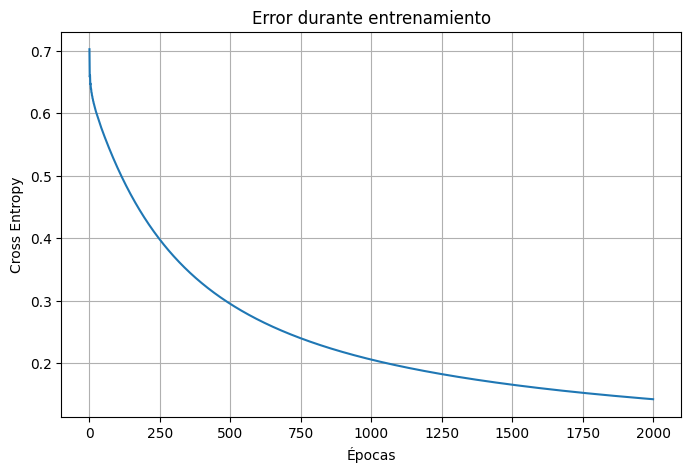

In [12]:
plt.figure(figsize=(8,5))

plt.plot(errors)

plt.xlabel('Épocas')

plt.ylabel('Cross Entropy')

plt.title('Error durante entrenamiento')

plt.grid(True)

plt.show()

# Paso 9 - Graficar frontera de clasificación

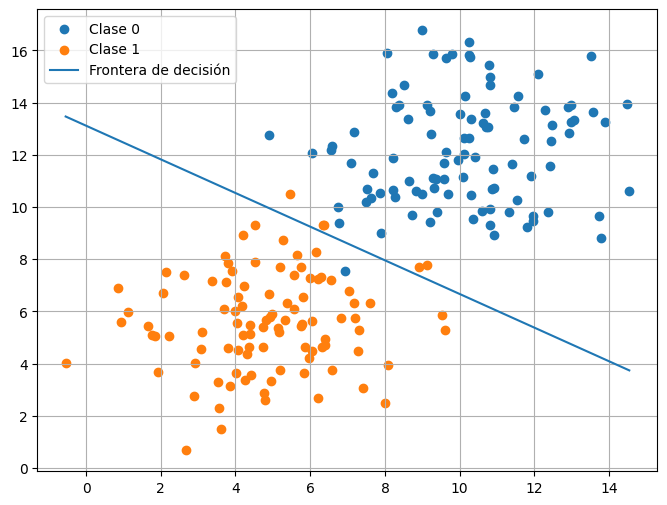

In [13]:
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    top_region[:,0],
    top_region[:,1],
    label='Clase 0'
)

ax.scatter(
    bottom_region[:,0],
    bottom_region[:,1],
    label='Clase 1'
)

# Extraer parámetros

w1 = line_parameters.item(0)

w2 = line_parameters.item(1)

b = line_parameters.item(2)

# Crear línea

x1 = np.array([

    all_points[:,0].min(),

    all_points[:,0].max()

])

x2 = -b/w2 + x1*(-w1/w2)

ax.plot(
    x1,
    x2,
    label='Frontera de decisión'
)

ax.legend()

ax.grid(True)

plt.show()

# Paso 10 - Predicciones

In [14]:
def predict(points, line_parameters):

    probabilities = sigmoid(
        points @ line_parameters
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    return probabilities, predictions

In [15]:
probabilities, predictions = predict(

    all_points,

    line_parameters

)

accuracy = np.mean(
    predictions == y
)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9700


# Paso 11 - Matriz de confusión

In [16]:
tp = np.sum(
    (predictions == 1) & (y == 1)
)

tn = np.sum(
    (predictions == 0) & (y == 0)
)

fp = np.sum(
    (predictions == 1) & (y == 0)
)

fn = np.sum(
    (predictions == 0) & (y == 1)
)

confusion = np.array([

    [tn, fp],

    [fn, tp]

])

print(confusion)

[[99  1]
 [ 5 95]]


# Paso 12 - Diferencia entre perceptrón y logistic regression

| Concepto | Perceptrón | Logistic Regression |
|---|---|---|
| Salida | 0 o 1 | Probabilidad |
| Activación | Escalón | Sigmoide |
| Loss | Error clasificación | Cross Entropy |
| Entrenamiento | Regla perceptrón | Gradient Descent |
| Interpretación | Clasificador lineal | Clasificador probabilístico |

Conclusión:

La regresión logística puede verse como una neurona simple con función sigmoide y entrenamiento mediante Cross Entropy + Gradient Descent.